# Swin-T Ablation Analysis
Validation curves and test-set metrics for each ablation axis: optimizer, learning rate, and imbalance strategy.

In [1]:
import sys
import os
import re
import json
import importlib.util
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, roc_auc_score

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(ROOT, 'src'))

from dataset import get_loaders, NUM_CLASSES, CLASS_NAMES

def load_module(name, filepath):
    spec = importlib.util.spec_from_file_location(name, filepath)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

model_mod  = load_module('swin_t', os.path.join(ROOT, 'src', 'swin_t', 'swin_t.py'))
build_swin_tiny = model_mod.build_swin_tiny

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ABLATION_ROOT = os.path.join(ROOT, 'results', 'swin_t', 'ablation')
print(f'Device: {device}')

Device: cuda


In [2]:
_, _, test_loader = get_loaders()
print(f'Test batches: {len(test_loader)}')

Test batches: 32


In [3]:
def parse_training_log(log_path):
    history = {'val_loss': [], 'val_acc': []}
    pattern = re.compile(r'val_loss=([\d.]+)\s+val_acc=([\d.]+)%')
    with open(log_path) as f:
        for line in f:
            m = pattern.search(line)
            if m:
                history['val_loss'].append(float(m.group(1)))
                history['val_acc'].append(float(m.group(2)))
    return history

def get_predictions(model, loader, device):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

def compute_metrics(pth_path):
    model = build_swin_tiny(num_classes=NUM_CLASSES)
    model.load_state_dict(torch.load(pth_path, map_location=device))
    model.to(device).eval()
    labels, preds, probs = get_predictions(model, test_loader, device)
    label_matrix = np.eye(NUM_CLASSES)[labels]
    return {
        'accuracy':      (preds == labels).mean() * 100,
        'macro_auc':     roc_auc_score(label_matrix, probs, average='macro', multi_class='ovr'),
        'micro_auc':     roc_auc_score(label_matrix, probs, average='micro', multi_class='ovr'),
        'per_class_auc': roc_auc_score(label_matrix, probs, average=None,   multi_class='ovr'),
        'report':        classification_report(labels, preds, target_names=CLASS_NAMES, zero_division=0),
    }

def plot_val_curves(runs, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, h in runs.items():
        epochs = range(1, len(h['val_loss']) + 1)
        axes[0].plot(epochs, h['val_loss'], label=name)
        axes[1].plot(epochs, h['val_acc'],  label=name)
    for ax, ylabel in zip(axes, ['Val Loss', 'Val Accuracy (%)']):
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{title} — {ylabel}')
        ax.legend()
        ax.grid(True)
    plt.tight_layout()
    plt.show()

def print_metrics_table(metrics_dict):
    print(f"{'Run':<30}  {'Accuracy':>10}  {'Macro AUC':>10}  {'Micro AUC':>10}")
    print('-' * 68)
    for name, m in metrics_dict.items():
        print(f"{name:<30}  {m['accuracy']:>9.2f}%  {m['macro_auc']:>10.4f}  {m['micro_auc']:>10.4f}")
    print(f"\nPer-class AUC")
    print(f"{'Class':<25}", end='')
    for name in metrics_dict:
        print(f"  {name:>12}", end='')
    print()
    print('-' * (25 + 14 * len(metrics_dict)))
    for i, cls in enumerate(CLASS_NAMES):
        print(f"{cls:<25}", end='')
        for m in metrics_dict.values():
            print(f"  {m['per_class_auc'][i]:>12.4f}", end='')
        print()

def print_classification_reports(metrics_dict):
    for name, m in metrics_dict.items():
        print(f'\n--- {name} ---')
        print(m['report'])

---
## Axis 1: Optimizer
Fixed: `lr=1e-3`, `imbalance=none`

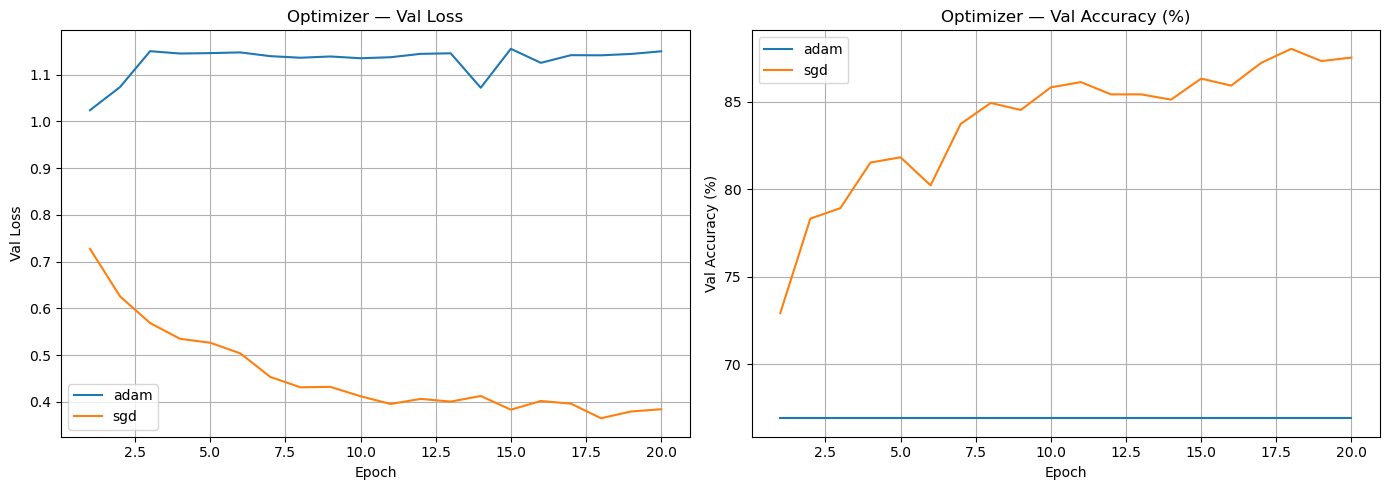

In [4]:
opt_runs = {
    'adam': parse_training_log(os.path.join(ABLATION_ROOT, 'optimizer', 'adam', 'training_log.txt')),
    'sgd':  parse_training_log(os.path.join(ABLATION_ROOT, 'optimizer', 'sgd',  'training_log.txt')),
}
plot_val_curves(opt_runs, 'Optimizer')

In [5]:
opt_pths = {
    'adam': os.path.join(ABLATION_ROOT, 'optimizer', 'adam', 'adam_lr0.001_none.pth'),
    'sgd':  os.path.join(ABLATION_ROOT, 'optimizer', 'sgd',  'sgd_lr0.001_none.pth'),
}
opt_metrics = {}
for name, path in opt_pths.items():
    print(f'Evaluating {name}...', end=' ', flush=True)
    opt_metrics[name] = compute_metrics(path)
    print('done')

print_metrics_table(opt_metrics)

Evaluating adam... 

done
Evaluating sgd... done
Run                               Accuracy   Macro AUC   Micro AUC
--------------------------------------------------------------------
adam                                66.97%      0.5384      0.8751
sgd                                 84.63%      0.9758      0.9871

Per-class AUC
Class                              adam           sgd
-----------------------------------------------------
MEL                              0.5914        0.9340
NV                               0.4608        0.9631
BCC                              0.6236        0.9937
AKIEC                            0.4251        0.9784
BKL                              0.4396        0.9644
DF                               0.5610        0.9976
VASC                             0.6673        0.9994


In [6]:
print_classification_reports(opt_metrics)


--- adam ---
              precision    recall  f1-score   support

         MEL       0.00      0.00      0.00       112
          NV       0.67      1.00      0.80       671
         BCC       0.00      0.00      0.00        52
       AKIEC       0.00      0.00      0.00        32
         BKL       0.00      0.00      0.00       110
          DF       0.00      0.00      0.00        11
        VASC       0.00      0.00      0.00        14

    accuracy                           0.67      1002
   macro avg       0.10      0.14      0.11      1002
weighted avg       0.45      0.67      0.54      1002


--- sgd ---
              precision    recall  f1-score   support

         MEL       0.68      0.51      0.58       112
          NV       0.87      0.97      0.92       671
         BCC       0.81      0.81      0.81        52
       AKIEC       0.75      0.56      0.64        32
         BKL       0.81      0.57      0.67       110
          DF       0.83      0.91      0.87        

---
## Axis 2: Learning Rate
Fixed: best optimizer from Axis 1, `imbalance=none`

Best optimizer: sgd


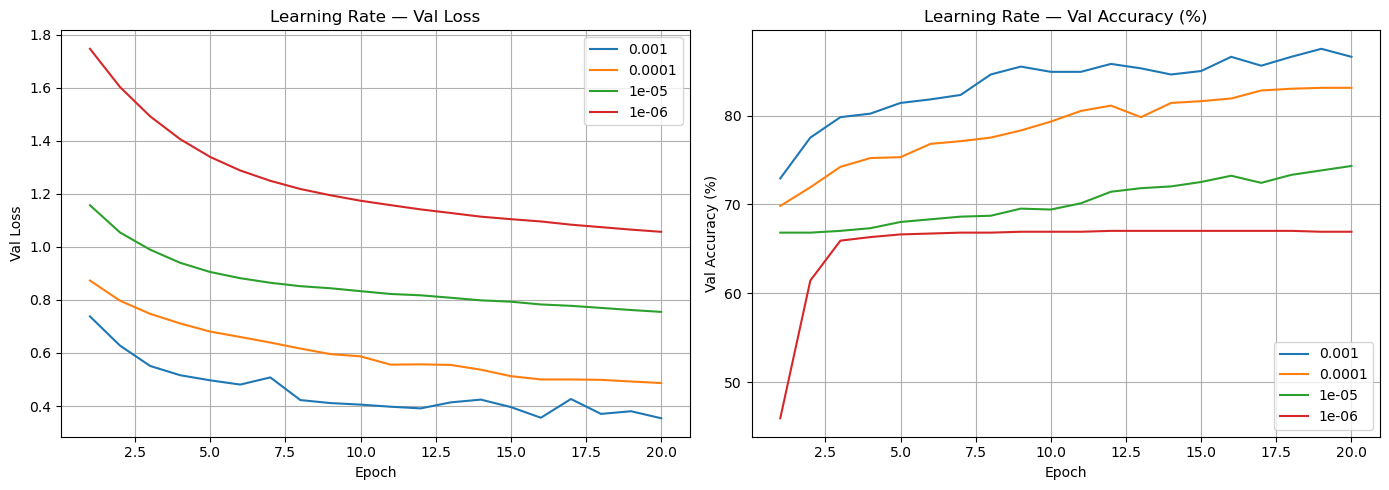

In [7]:
LR_VALUES = ['0.001', '0.0001', '1e-05', '1e-06']

with open(os.path.join(ABLATION_ROOT, 'summary.json')) as f:
    summary = json.load(f)
best_opt = summary['best_config']['optimizer']
print(f'Best optimizer: {best_opt}')

lr_runs = {
    lr: parse_training_log(os.path.join(ABLATION_ROOT, 'lr', lr, 'training_log.txt'))
    for lr in LR_VALUES
}
plot_val_curves(lr_runs, 'Learning Rate')

In [8]:
lr_pths = {
    lr: os.path.join(ABLATION_ROOT, 'lr', lr, f'{best_opt}_lr{lr}_none.pth')
    for lr in LR_VALUES
}
lr_metrics = {}
for name, path in lr_pths.items():
    print(f'Evaluating lr={name}...', end=' ', flush=True)
    lr_metrics[name] = compute_metrics(path)
    print('done')

print_metrics_table(lr_metrics)

Evaluating lr=0.001... done
Evaluating lr=0.0001... done
Evaluating lr=1e-05... done
Evaluating lr=1e-06... done
Run                               Accuracy   Macro AUC   Micro AUC
--------------------------------------------------------------------
0.001                               86.03%      0.9751      0.9868
0.0001                              82.53%      0.9586      0.9793
1e-05                               73.95%      0.8927      0.9552
1e-06                               66.97%      0.7504      0.9125

Per-class AUC
Class                             0.001        0.0001         1e-05         1e-06
---------------------------------------------------------------------------------
MEL                              0.9354        0.9191        0.8384        0.7199
NV                               0.9642        0.9571        0.9241        0.8173
BCC                              0.9956        0.9829        0.9298        0.7435
AKIEC                            0.9749        0.9664     

In [9]:
print_classification_reports(lr_metrics)


--- 0.001 ---
              precision    recall  f1-score   support

         MEL       0.67      0.58      0.62       112
          NV       0.93      0.93      0.93       671
         BCC       0.84      0.88      0.86        52
       AKIEC       0.57      0.84      0.68        32
         BKL       0.75      0.70      0.72       110
          DF       0.73      0.73      0.73        11
        VASC       0.88      1.00      0.93        14

    accuracy                           0.86      1002
   macro avg       0.77      0.81      0.78      1002
weighted avg       0.86      0.86      0.86      1002


--- 0.0001 ---
              precision    recall  f1-score   support

         MEL       0.74      0.50      0.60       112
          NV       0.87      0.97      0.92       671
         BCC       0.69      0.83      0.75        52
       AKIEC       0.54      0.44      0.48        32
         BKL       0.69      0.44      0.53       110
          DF       1.00      0.27      0.43    

---
## Axis 3: Imbalance Strategy
Fixed: best optimizer + best LR from Axes 1 & 2

Best optimizer: sgd | Best LR: 0.001


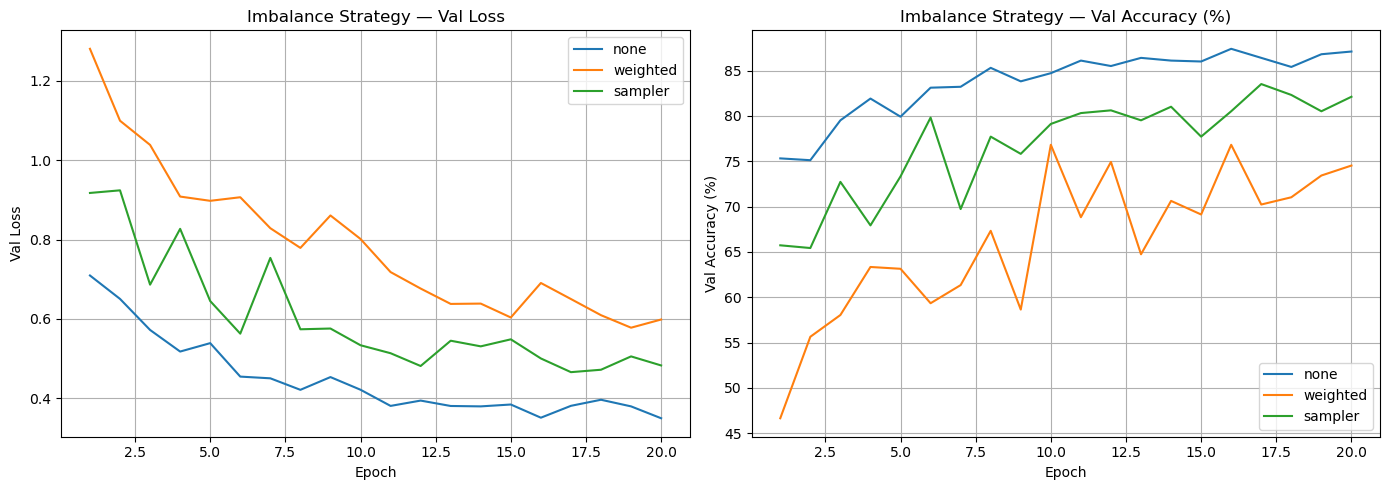

In [10]:
best_lr = str(summary['best_config']['lr'])
print(f'Best optimizer: {best_opt} | Best LR: {best_lr}')

IMB_VALUES = ['none', 'weighted', 'sampler']
imb_runs = {
    imb: parse_training_log(os.path.join(ABLATION_ROOT, 'imbalance', imb, 'training_log.txt'))
    for imb in IMB_VALUES
}
plot_val_curves(imb_runs, 'Imbalance Strategy')

In [11]:
imb_pths = {
    imb: os.path.join(ABLATION_ROOT, 'imbalance', imb, f'{best_opt}_lr{best_lr}_{imb}.pth')
    for imb in IMB_VALUES
}
imb_metrics = {}
for name, path in imb_pths.items():
    print(f'Evaluating {name}...', end=' ', flush=True)
    imb_metrics[name] = compute_metrics(path)
    print('done')

print_metrics_table(imb_metrics)

Evaluating none... done
Evaluating weighted... done
Evaluating sampler... done
Run                               Accuracy   Macro AUC   Micro AUC
--------------------------------------------------------------------
none                                87.33%      0.9784      0.9887
weighted                            75.95%      0.9617      0.9698
sampler                             81.74%      0.9772      0.9832

Per-class AUC
Class                              none      weighted       sampler
-------------------------------------------------------------------
MEL                              0.9473        0.8921        0.9420
NV                               0.9689        0.9485        0.9583
BCC                              0.9961        0.9937        0.9975
AKIEC                            0.9728        0.9704        0.9826
BKL                              0.9660        0.9281        0.9607
DF                               0.9978        0.9996        0.9998
VASC                     

In [12]:
print_classification_reports(imb_metrics)


--- none ---
              precision    recall  f1-score   support

         MEL       0.72      0.65      0.68       112
          NV       0.93      0.94      0.94       671
         BCC       0.91      0.81      0.86        52
       AKIEC       0.57      0.75      0.65        32
         BKL       0.77      0.75      0.76       110
          DF       0.89      0.73      0.80        11
        VASC       0.87      0.93      0.90        14

    accuracy                           0.87      1002
   macro avg       0.81      0.79      0.80      1002
weighted avg       0.87      0.87      0.87      1002


--- weighted ---
              precision    recall  f1-score   support

         MEL       0.39      0.69      0.50       112
          NV       0.96      0.78      0.86       671
         BCC       0.70      0.90      0.79        52
       AKIEC       0.40      0.84      0.54        32
         BKL       0.69      0.54      0.61       110
          DF       0.85      1.00      0.92   

---
## Best Config Summary

In [13]:
print(json.dumps(summary['best_config'], indent=2))

{
  "optimizer": "sgd",
  "lr": 0.001,
  "imbalance": "none"
}
